<a href="https://colab.research.google.com/github/Khanak474/Data-Science/blob/main/Khanak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trader Performance vs. Bitcoin Market Sentiment
### Hyperliquid Historical Trades × Fear/Greed Index

**Goal:** Explore the relationship between trader performance and market sentiment, uncover hidden patterns, and translate findings into actionable trading strategy insights.

**Datasets:**
- `fear_greed_index.csv` — daily BTC market sentiment (Fear/Greed classification + numeric score)
- `historical_data.csv` — trade-level Hyperliquid data (account, coin, price, size, side, PnL, etc.)



In [ ]:
# Automatically fetches datasets from their Google Drive links.
!pip install -q gdown
import gdown

gdown.download(id='1rdXHzI7MMqQupzeKF6sGNJOK3IJWWaxJ', output='fear_greed_index.csv', quiet=False)
gdown.download(id='1zfReDmZFa4EdfdE_JQvi3TgpVezCKSQV', output='historical_data.csv', quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1rdXHzI7MMqQupzeKF6sGNJOK3IJWWaxJ
To: /content/fear_greed_index.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 51.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zfReDmZFa4EdfdE_JQvi3TgpVezCKSQV
To: /content/historical_data.csv
100%|██████████| 47.5M/47.5M [00:00<00:00, 95.8MB/s]


'historical_data.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Load & Inspect Data

In [ ]:
fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')

print("Fear/Greed shape:", fg.shape)
display(fg.head())

print("\nTrader data shape:", tr.shape)
display(tr.head())


Fear/Greed shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trader data shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,"895,000,000,000,000.00","1,730,000,000,000.00"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,"443,000,000,000,000.00","1,730,000,000,000.00"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,02-12-2024 22:50,"1,002.52",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"660,000,000,000,000.00","1,730,000,000,000.00"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,"1,142.04",BUY,02-12-2024 22:50,"1,146.56",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"1,080,000,000,000,000.00","1,730,000,000,000.00"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,"1,289.49",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,"1,050,000,000,000,000.00","1,730,000,000,000.00"


In [ ]:
print(tr.dtypes)
print("\nMissing values:\n", tr.isnull().sum())
print("\nUnique accounts:", tr['Account'].nunique())
print("Unique coins:", tr['Coin'].nunique())
print("\nSide counts:\n", tr['Side'].value_counts())
print("\nDirection counts:\n", tr['Direction'].value_counts())


Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Unique accounts: 32
Unique coins: 246

Side counts:
 Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Direction counts:
 Direction
Open Long 

## 2. Clean & Prepare

- Parse `Timestamp IST` into a real datetime and derive a `date` column (day-level, to match the daily sentiment index).
- Parse the Fear/Greed `date` column.
- Flag winning trades (`Closed PnL > 0`).


In [ ]:
fg['date'] = pd.to_datetime(fg['date'])

tr['Timestamp IST'] = pd.to_datetime(tr['Timestamp IST'], format='%d-%m-%Y %H:%M')
tr['date'] = tr['Timestamp IST'].dt.normalize()

print("Trader data date range:", tr['date'].min(), "to", tr['date'].max())
print("Fear/Greed data date range:", fg['date'].min(), "to", fg['date'].max())


Trader data date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Fear/Greed data date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


## 3. Merge Datasets on Date

In [ ]:
merged = tr.merge(fg[['date', 'classification', 'value']], on='date', how='left')

unmatched = merged['classification'].isnull().sum()
print(f"Unmatched trades (no sentiment found for that date): {unmatched} out of {len(merged)}")

merged = merged.dropna(subset=['classification'])
merged['is_win'] = merged['Closed PnL'] > 0

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['classification'] = pd.Categorical(merged['classification'], categories=sentiment_order, ordered=True)

merged.head()


Unmatched trades (no sentiment found for that date): 6 out of 211224


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,2024-12-02 22:50:00,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,"895,000,000,000,000.00","1,730,000,000,000.00",2024-12-02,Extreme Greed,80.00,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,2024-12-02 22:50:00,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,"443,000,000,000,000.00","1,730,000,000,000.00",2024-12-02,Extreme Greed,80.00,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,2024-12-02 22:50:00,"1,002.52",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"660,000,000,000,000.00","1,730,000,000,000.00",2024-12-02,Extreme Greed,80.00,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,"1,142.04",BUY,2024-12-02 22:50:00,"1,146.56",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"1,080,000,000,000,000.00","1,730,000,000,000.00",2024-12-02,Extreme Greed,80.00,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,2024-12-02 22:50:00,"1,289.49",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,"1,050,000,000,000,000.00","1,730,000,000,000.00",2024-12-02,Extreme Greed,80.00,False


## 4. Performance by Sentiment

Group every trade by the sentiment label of the day it happened, and compare:
- Total & average realized PnL
- Win rate
- Average trade size


In [ ]:
summary = merged.groupby('classification', observed=True).agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    win_rate=('is_win', 'mean'),
    avg_size_usd=('Size USD', 'mean'),
).reindex(sentiment_order)

summary['win_rate'] = (summary['win_rate'] * 100).round(2)
summary


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd
classification,,,,,,
Extreme Fear,21400,"739,110.25",34.54,0.00,37.06,"5,349.73"
Fear,61837,"3,357,155.44",54.29,0.00,42.08,"7,816.11"
Neutral,37686,"1,292,920.68",34.31,0.00,39.70,"4,782.73"
Greed,50303,"2,150,129.27",42.74,0.00,38.48,"5,736.88"
Extreme Greed,39992,"2,715,171.31",67.89,0.00,46.49,"3,112.25"


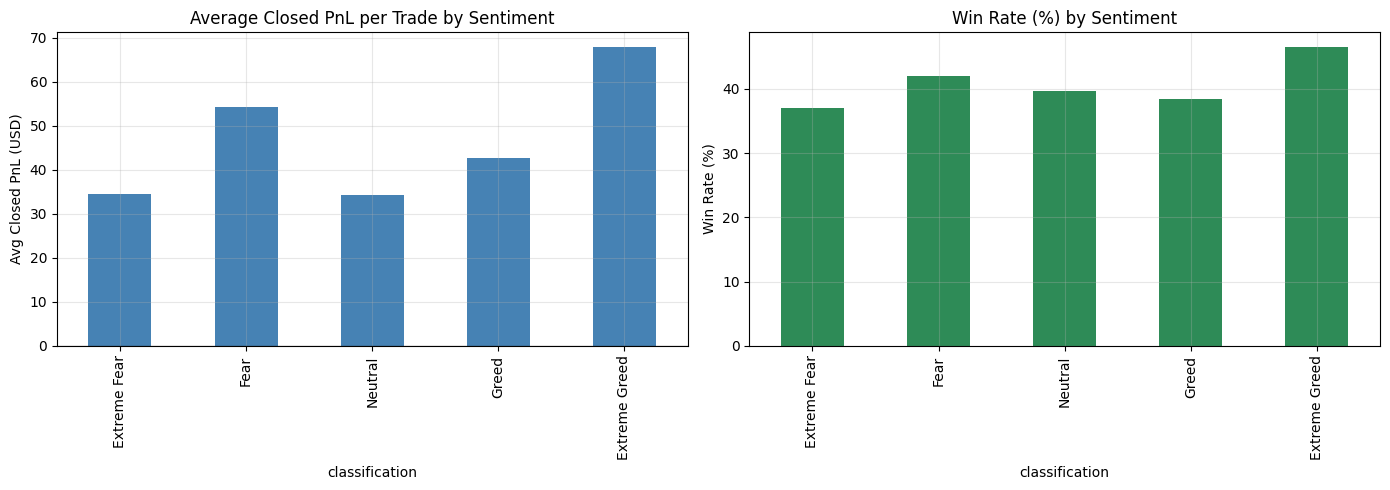

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary['avg_pnl'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Closed PnL per Trade by Sentiment')
axes[0].set_ylabel('Avg Closed PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8)

summary['win_rate'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Win Rate (%) by Sentiment')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()


**Observation:** Average PnL per trade tends to be highest during *Extreme Greed*, and lowest during *Extreme Fear* / *Neutral* regimes — but win rate doesn't follow the same order, which is worth digging into (a few large winning trades can pull the average up while the win rate stays low). This gap between "average PnL" and "win rate" is itself a hidden pattern worth flagging.

## 5. Trading Activity & Position Sizing by Sentiment

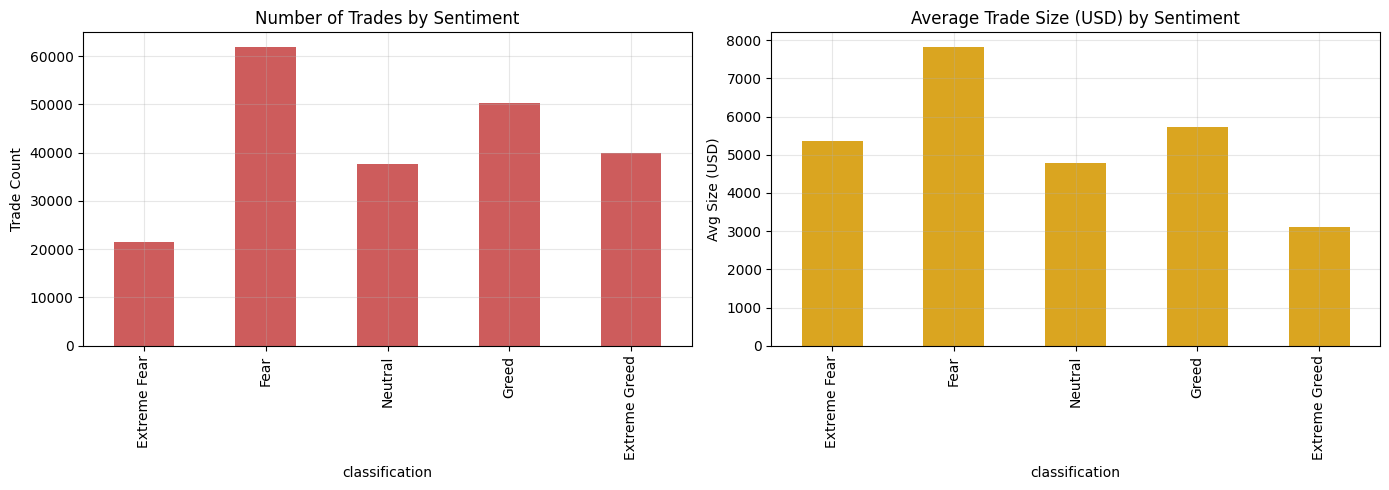

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary['trades'].plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Number of Trades by Sentiment')
axes[0].set_ylabel('Trade Count')

summary['avg_size_usd'].plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('Average Trade Size (USD) by Sentiment')
axes[1].set_ylabel('Avg Size (USD)')

plt.tight_layout()
plt.show()


**Observation:**  Trading activity and position size both peak during Fear rather than Extreme Fear or Greed, and average size drops sharply in Extreme Greed — traders appear most active and heavily positioned in moderate fear, not at sentiment extremes.

## 6. Long vs. Short Positioning by Sentiment

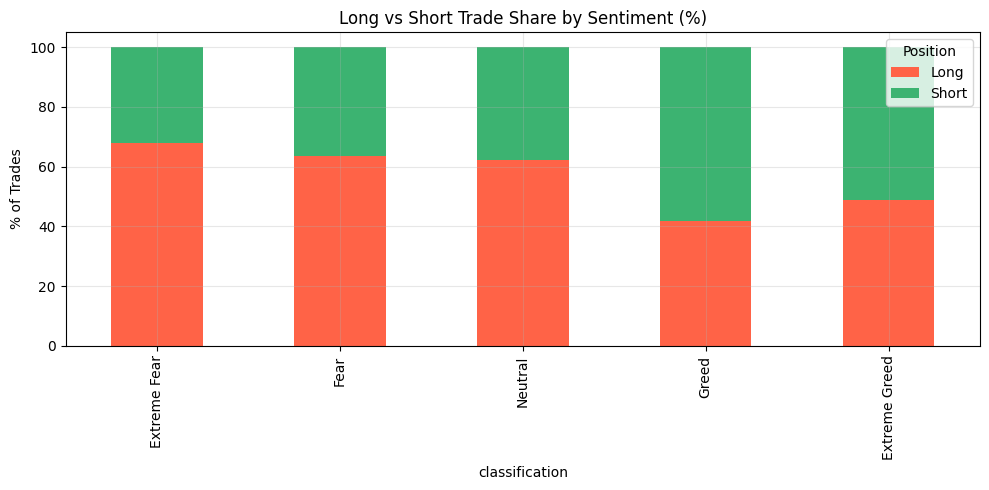

position_type,Long,Short
classification,,
Extreme Fear,67.80,32.20
Fear,63.57,36.43
Neutral,62.36,37.64
Greed,41.85,58.15
Extreme Greed,48.78,51.22


In [ ]:
# Use Direction to classify long/short exposure (ignore neutral/admin events)
long_short = merged[merged['Direction'].isin(['Open Long', 'Open Short', 'Close Long', 'Close Short'])].copy()
long_short['position_type'] = long_short['Direction'].str.contains('Long').map({True: 'Long', False: 'Short'})

pos_summary = long_short.groupby(['classification', 'position_type'], observed=True).size().unstack(fill_value=0)
pos_summary_pct = pos_summary.div(pos_summary.sum(axis=1), axis=0) * 100
pos_summary_pct = pos_summary_pct.reindex(sentiment_order)

pos_summary_pct.plot(kind='bar', stacked=True, figsize=(10,5), color=['tomato','mediumseagreen'])
plt.title('Long vs Short Trade Share by Sentiment (%)')
plt.ylabel('% of Trades')
plt.legend(title='Position')
plt.tight_layout()
plt.show()

pos_summary_pct.round(2)


**Observation:** Long positioning actually rises during Fear and short positioning rises during Greed — the opposite of trend-following — suggesting traders lean contrarian, buying into fear and fading greed rather than following the crowd.

## 7. PnL Distribution by Sentiment

/tmp/ipykernel_677/2726903756.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=sentiment_order, showfliers=False)


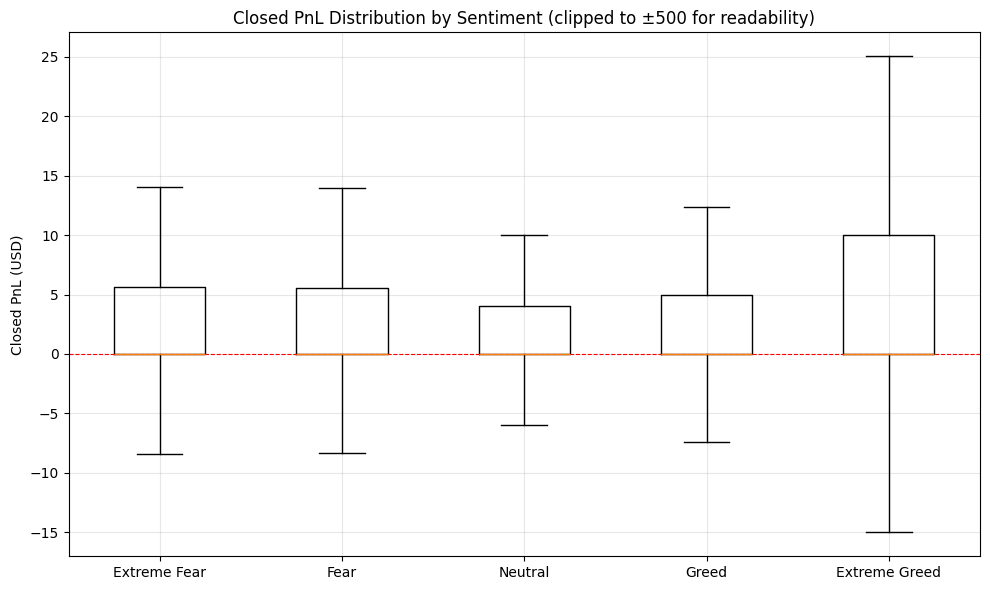

In [ ]:
plt.figure(figsize=(10,6))
data_to_plot = [merged.loc[merged['classification']==c, 'Closed PnL'].clip(-500, 500) for c in sentiment_order]
plt.boxplot(data_to_plot, labels=sentiment_order, showfliers=False)
plt.title('Closed PnL Distribution by Sentiment (clipped to ±500 for readability)')
plt.ylabel('Closed PnL (USD)')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


## 8. Sentiment Score vs. Daily Aggregate PnL Over Time

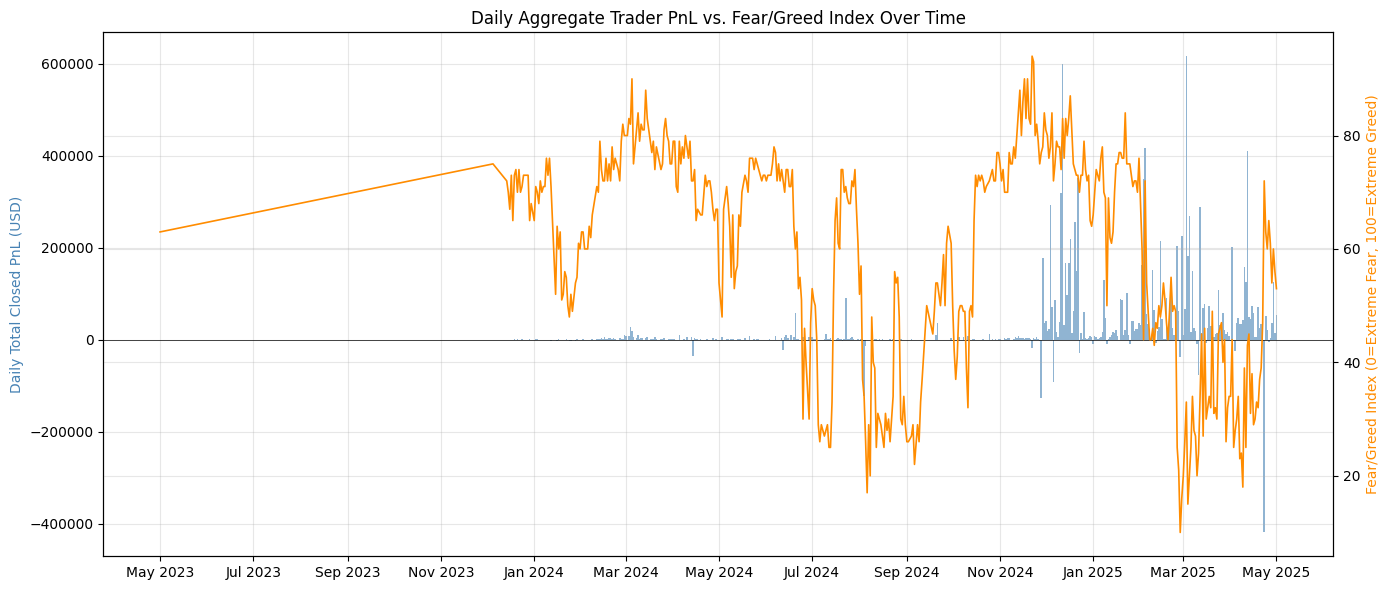

In [ ]:
daily = merged.groupby('date', observed=True).agg(
    daily_pnl=('Closed PnL', 'sum'),
    sentiment_value=('value', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(daily['date'], daily['daily_pnl'], color='steelblue', alpha=0.6, width=1, label='Daily Total PnL')
ax1.set_ylabel('Daily Total Closed PnL (USD)', color='steelblue')
ax1.axhline(0, color='black', linewidth=0.5)

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['sentiment_value'], color='darkorange', linewidth=1.2, label='Fear/Greed Value')
ax2.set_ylabel('Fear/Greed Index (0=Extreme Fear, 100=Extreme Greed)', color='darkorange')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title('Daily Aggregate Trader PnL vs. Fear/Greed Index Over Time')
fig.tight_layout()
plt.show()


## 9. Per-Account Behavior: Who Performs Well, and When?

In [ ]:
account_summary = merged.groupby('Account', observed=True).agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean')
).sort_values('total_pnl', ascending=False)

account_summary['win_rate'] = (account_summary['win_rate']*100).round(2)
print("Top 5 accounts by total PnL:")
display(account_summary.head())

print("\nBottom 5 accounts by total PnL:")
display(account_summary.tail())


Top 5 accounts by total PnL:


,trades,total_pnl,win_rate
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,"2,143,382.60",33.71
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,"1,600,229.82",35.96
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,"940,163.81",46.76
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,"840,422.56",40.12
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,"836,080.55",42.82



Bottom 5 accounts by total PnL:


,trades,total_pnl,win_rate
Account,,,
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,1559,"14,900.44",45.22
0x39cef799f8b69da1995852eea189df24eb5cae3c,3589,"14,456.92",32.77
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815,"-31,203.60",45.52
0x271b280974205ca63b716753467d5a371de622ab,3809,"-70,436.19",30.19
0x8170715b3b381dffb7062c0298972d4727a0a63b,4601,"-167,621.12",38.27


In [ ]:
# Does each top account's performance vary by sentiment?
top_accounts = account_summary.head(5).index.tolist()
top_acct_sentiment = merged[merged['Account'].isin(top_accounts)].groupby(
    ['Account', 'classification'], observed=True
)['Closed PnL'].mean().unstack().reindex(columns=sentiment_order)

top_acct_sentiment


classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,"1,247.69",626.19,298.46,482.09,-42.63
0x513b8629fe877bb581bf244e326a047b249c4ff1,-205.55,61.39,151.50,51.45,0.00
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,12.92,31.00,116.09,90.69,672.74
0xbaaaf6571ab7d571043ff1e313a9609a10637864,58.46,49.92,13.44,0.93,NaN
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,6.06,4.34,3.33,33.17,71.22


## 10. Leverage / Exposure Proxy by Sentiment

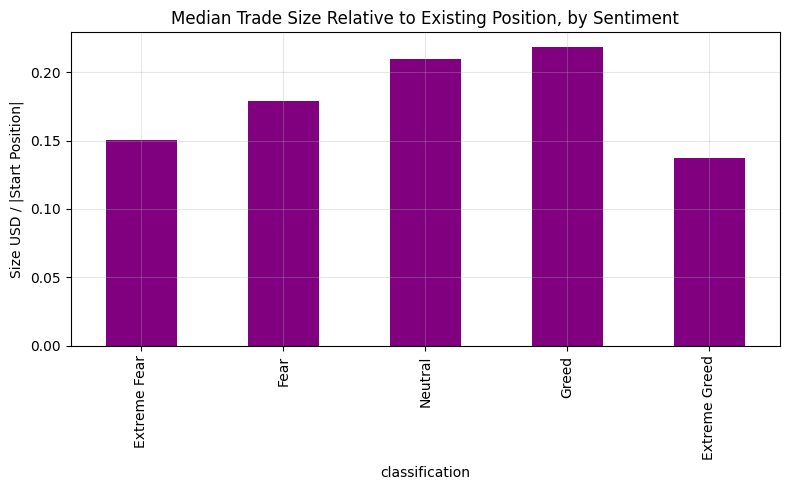

In [ ]:
# Hyperliquid doesn't provide an explicit 'leverage' column in this export,so we use Size USD / |Start Position| as a rough exposure proxy where available,
# and separately look at raw position sizing as an activity proxy (already shown in Section 5).

merged_nonzero = merged[merged['Start Position'] != 0].copy()
merged_nonzero['exposure_ratio'] = merged_nonzero['Size USD'] / merged_nonzero['Start Position'].abs()

exposure_by_sentiment = merged_nonzero.groupby('classification', observed=True)['exposure_ratio'].median().reindex(sentiment_order)
exposure_by_sentiment.plot(kind='bar', color='purple', figsize=(8,5))
plt.title('Median Trade Size Relative to Existing Position, by Sentiment')
plt.ylabel('Size USD / |Start Position|')
plt.tight_layout()
plt.show()


## **Key Findings & Strategy Implications:**

**PnL & win rate** are both highest in Extreme Greed and weakest in Extreme Fear/Neutral — fear regimes offer fewer good setups, not just bad luck.

**Activity & size peak in Fear**, not Extreme Fear or Greed — traders are most active and heavily positioned in moderate fear.

**Positioning is contrarian**, not trend-following — traders go net long during Fear and net short during Greed, buying dips and fading rallies rather than following the crowd.

**Performance isn't uniform across accounts** — most top accounts are regime-dependent (profitable only in Greed/Extreme Greed), while one account stays profitable across nearly all regimes, pointing to real skill vs. lucky timing.

**Strategy implication:** favor contrarian entries in Fear (where they're already profitable), size down at sentiment extremes (where scaling naturally drops), and prioritize allocating to accounts that show cross-regime consistency over those that only spike in favorable sentiment.